# **Ievads attēlu apstrādē**
## **Praktiskais darbs Nr. 7**
---

**Students:** Rihards Irbe

**Studenta apliecības Nr.:** 251RDB259

**Saite uz programmēšanas kodu:** https://colab.research.google.com/drive/1CF4om-GJxP8q3VupZHbvs7IzTu7b2uT2

---

## **Programmas kods ar izvadi**

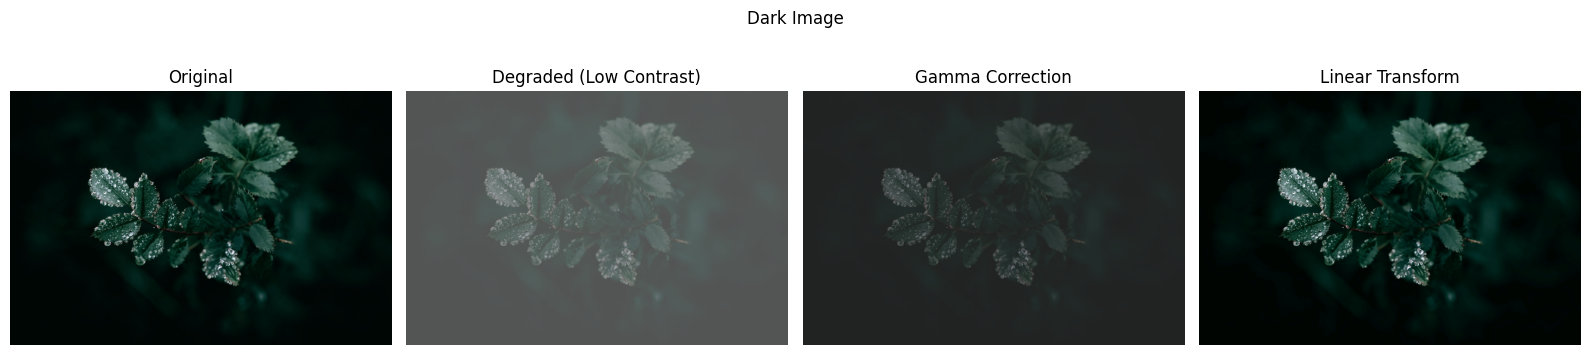

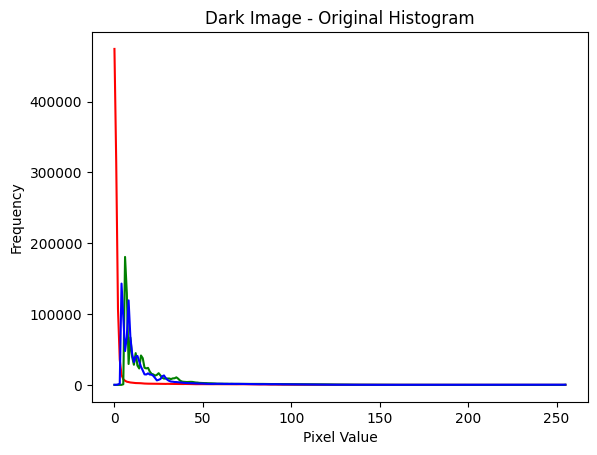

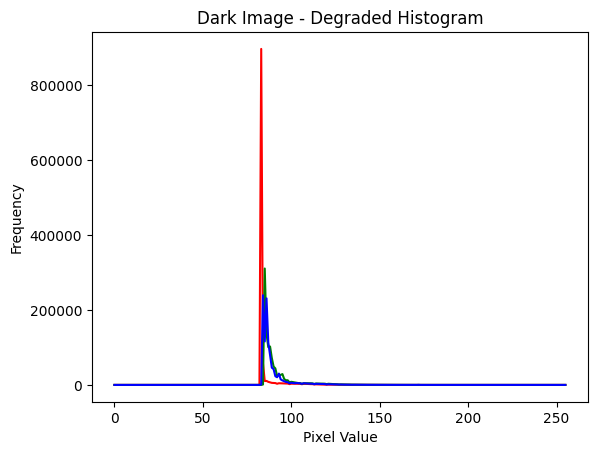

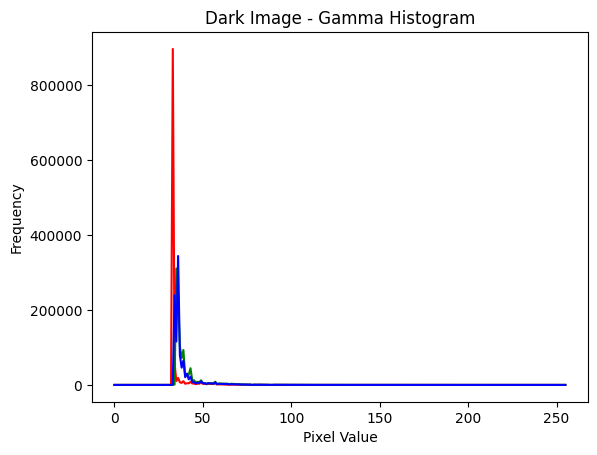

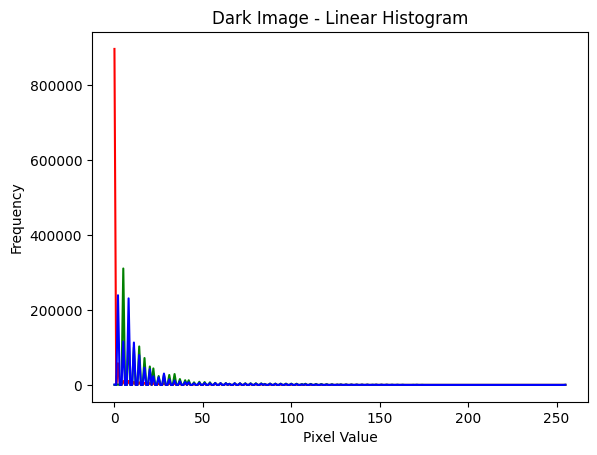

Rezultatu analize: Dark Image
Metode                    MSE   PSNR (dB)      SSIM
----------------------------------------------------
Degradets             5493.64       10.73    0.2415
Gamma korekcija        784.10       19.19    0.4177
Lineara transf.          1.92       45.30    0.9568

Labakais MSE  (zemaks = labaks): Lineara transf.  (1.92)
Labakais PSNR (augstaks = labaks): Lineara transf.  (45.30 dB)
Labakais SSIM (augstaks = labaks): Lineara transf.  (0.9568)



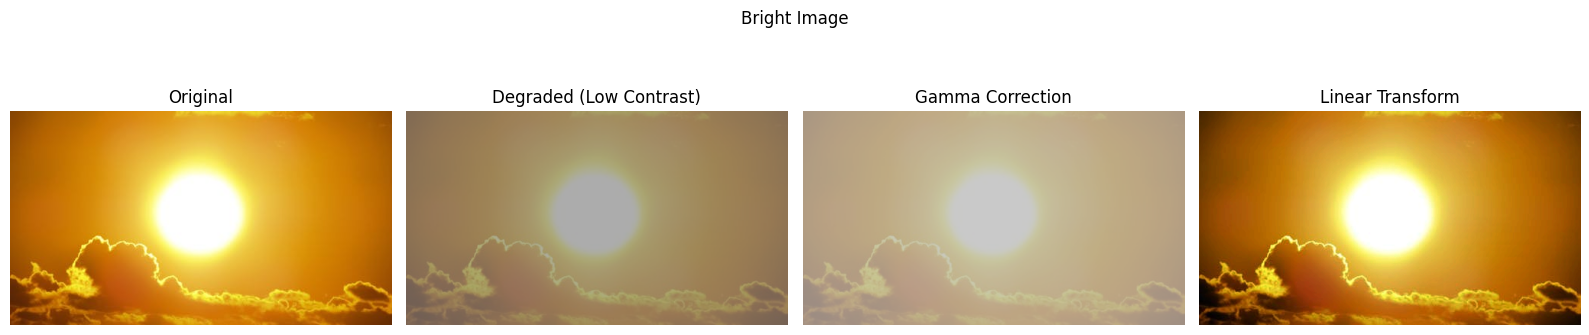

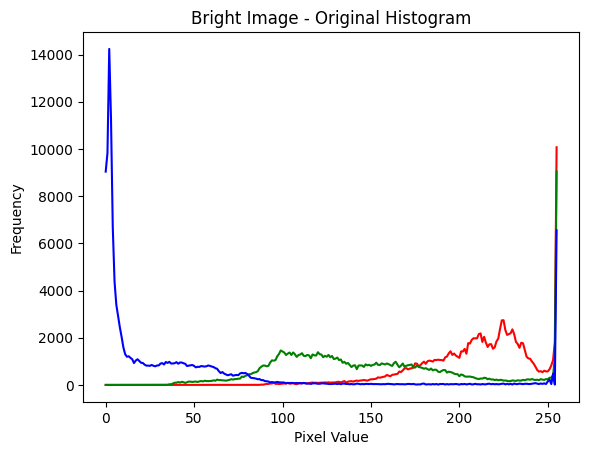

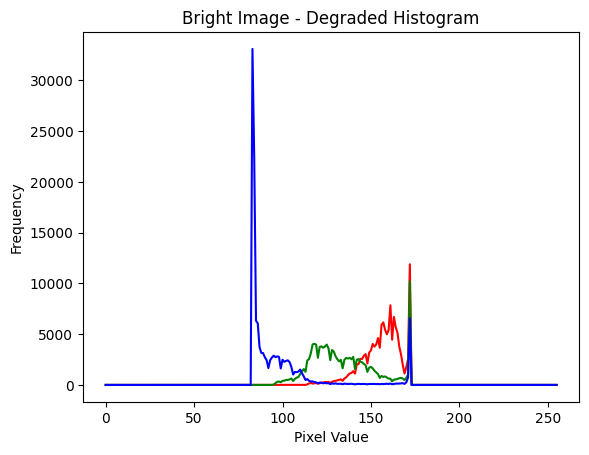

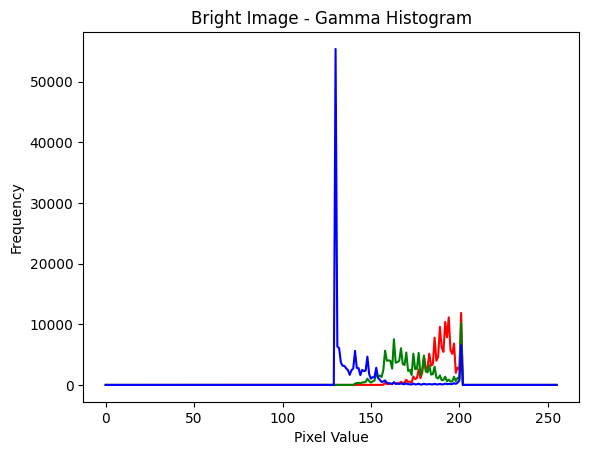

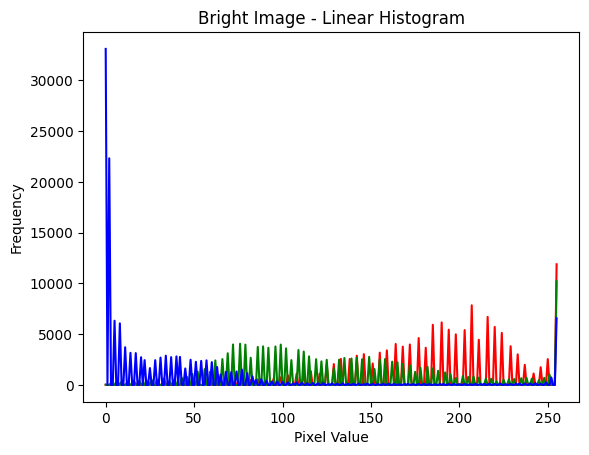

Rezultatu analize: Bright Image
Metode                    MSE   PSNR (dB)      SSIM
----------------------------------------------------
Degradets             3183.20       13.10    0.7321
Gamma korekcija       5099.97       11.06    0.6948
Lineara transf.        398.42       22.13    0.9493

Labakais MSE  (zemaks = labaks): Lineara transf.  (398.42)
Labakais PSNR (augstaks = labaks): Lineara transf.  (22.13 dB)
Labakais SSIM (augstaks = labaks): Lineara transf.  (0.9493)



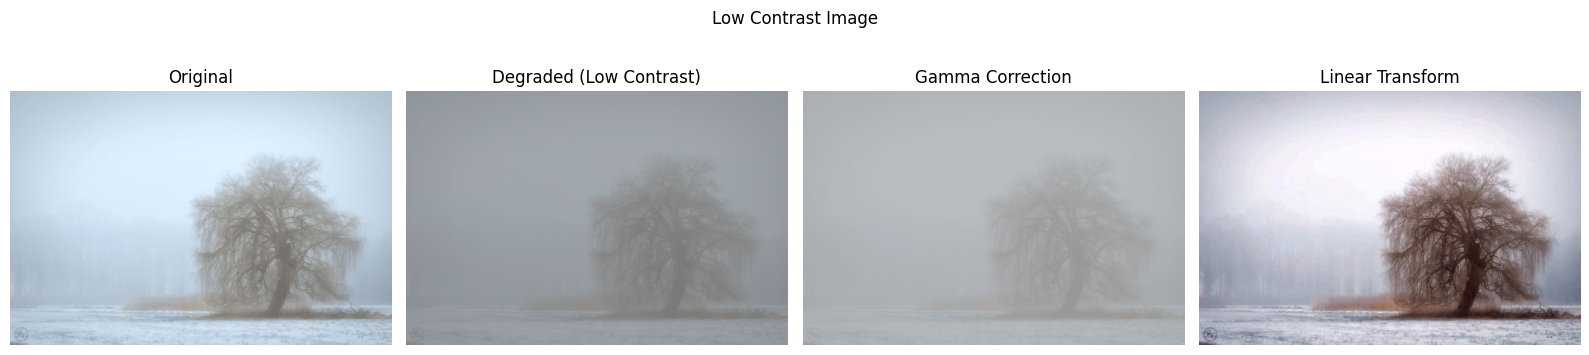

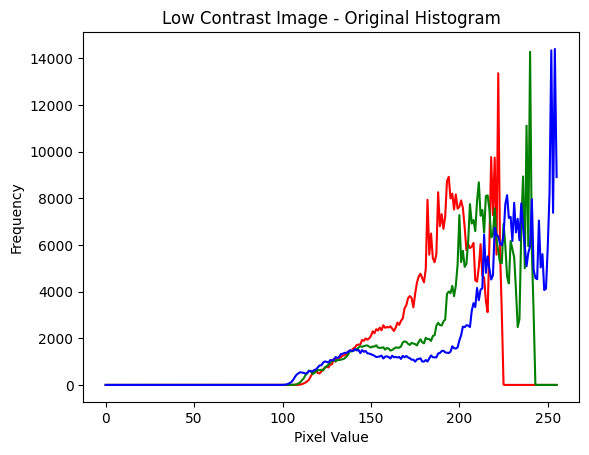

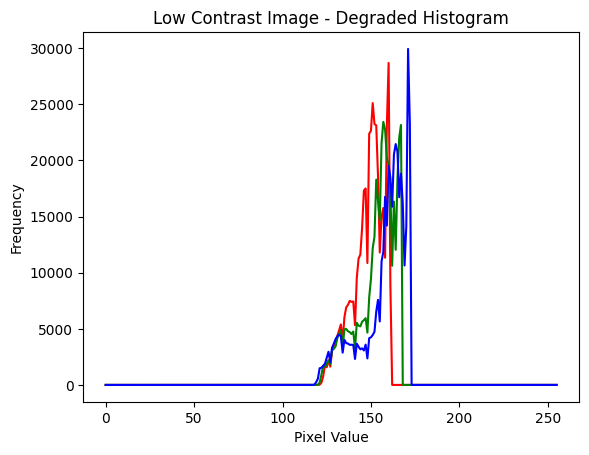

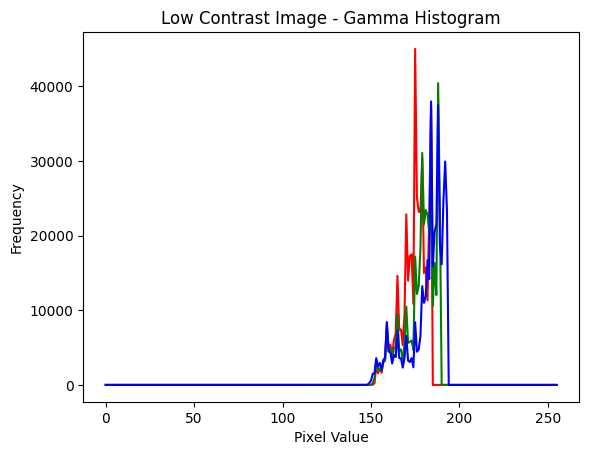

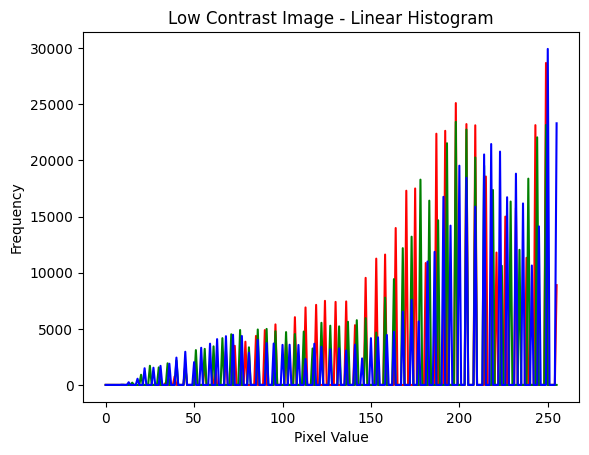

Rezultatu analize: Low Contrast Image
Metode                    MSE   PSNR (dB)      SSIM
----------------------------------------------------
Degradets             2766.96       13.71    0.8987
Gamma korekcija       1096.97       17.73    0.9086
Lineara transf.        939.80       18.40    0.9113

Labakais MSE  (zemaks = labaks): Lineara transf.  (939.80)
Labakais PSNR (augstaks = labaks): Lineara transf.  (18.40 dB)
Labakais SSIM (augstaks = labaks): Lineara transf.  (0.9113)



In [ ]:
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np
from skimage.metrics import structural_similarity as ssim_metric


def load_image(url):
    headers = {
        "User-Agent": "Mozilla/5.0"
    }
    response = requests.get(url, headers=headers)
    img = Image.open(BytesIO(response.content)).convert("RGB")
    return img


def gamma_correction(image, gamma):
    width, height = image.size
    pixels = image.load()

    new_img = Image.new("RGB", (width, height))
    new_pixels = new_img.load()

    for x in range(width):
        for y in range(height):
            r, g, b = pixels[x, y]

            r_new = int(255 * ((r / 255) ** gamma))
            g_new = int(255 * ((g / 255) ** gamma))
            b_new = int(255 * ((b / 255) ** gamma))

            new_pixels[x, y] = (r_new, g_new, b_new)

    return new_img


def find_darkest_pixel(hist):
    for i in range(256):
        if hist[i] > 0:
            return i
    return 0


def find_brightest_pixel(hist):
    for i in range(255, -1, -1):
        if hist[i] > 0:
            return i
    return 255


def linear_transform(image):
    width, height = image.size
    pixels = image.load()

    r_hist = [0] * 256
    g_hist = [0] * 256
    b_hist = [0] * 256

    for x in range(width):
        for y in range(height):
            r, g, b = pixels[x, y]
            r_hist[r] += 1
            g_hist[g] += 1
            b_hist[b] += 1

    desired_range = 255

    r_begin = find_darkest_pixel(r_hist)
    r_end = find_brightest_pixel(r_hist)
    g_begin = find_darkest_pixel(g_hist)
    g_end = find_brightest_pixel(g_hist)
    b_begin = find_darkest_pixel(b_hist)
    b_end = find_brightest_pixel(b_hist)

    r_range = r_end - r_begin
    g_range = g_end - g_begin
    b_range = b_end - b_begin

    r_stretch = desired_range / r_range if r_range != 0 else 1
    g_stretch = desired_range / g_range if g_range != 0 else 1
    b_stretch = desired_range / b_range if b_range != 0 else 1

    new_img = Image.new("RGB", (width, height))
    new_pixels = new_img.load()

    for x in range(width):
        for y in range(height):
            r, g, b = pixels[x, y]

            r_new = int(r_stretch * (r - r_begin))
            g_new = int(g_stretch * (g - g_begin))
            b_new = int(b_stretch * (b - b_begin))

            r_new = max(0, min(255, r_new))
            g_new = max(0, min(255, g_new))
            b_new = max(0, min(255, b_new))

            new_pixels[x, y] = (r_new, g_new, b_new)

    return new_img


def degrade_contrast(image):
    width, height = image.size
    pixels = image.load()

    new_img = Image.new("RGB", (width, height))
    new_pixels = new_img.load()

    for x in range(width):
        for y in range(height):
            r, g, b = pixels[x, y]

            r_new = int(128 + 0.35 * (r - 128))
            g_new = int(128 + 0.35 * (g - 128))
            b_new = int(128 + 0.35 * (b - 128))

            new_pixels[x, y] = (r_new, g_new, b_new)

    return new_img


def calculate_mse(img1, img2):
    arr1 = np.array(img1, dtype=np.float64)
    arr2 = np.array(img2, dtype=np.float64)
    return float(np.mean((arr1 - arr2) ** 2))


def calculate_psnr(img1, img2):
    mse = calculate_mse(img1, img2)
    if mse == 0:
        return float("inf")
    return float(10 * np.log10(255.0 ** 2 / mse))


def calculate_ssim(img1, img2):
    arr1 = np.array(img1)
    arr2 = np.array(img2)
    score, _ = ssim_metric(arr1, arr2, channel_axis=2, data_range=255, full=True)
    return float(score)


def calculate_histogram(image):
    width, height = image.size
    pixels = image.load()

    r_hist = [0] * 256
    g_hist = [0] * 256
    b_hist = [0] * 256

    for x in range(width):
        for y in range(height):
            r, g, b = pixels[x, y]
            r_hist[r] += 1
            g_hist[g] += 1
            b_hist[b] += 1

    return r_hist, g_hist, b_hist


def show_histogram(image, title):
    r_hist, g_hist, b_hist = calculate_histogram(image)

    plt.figure()
    plt.plot(r_hist, color="red")
    plt.plot(g_hist, color="green")
    plt.plot(b_hist, color="blue")

    plt.title(title)
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")
    plt.show()


def show_images(original, degraded, gamma_img, linear_img, title,
                mse_deg, psnr_deg, ssim_deg,
                mse_gamma, psnr_gamma, ssim_gamma,
                mse_linear, psnr_linear, ssim_linear):
    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(degraded)
    plt.title("Degraded (Low Contrast)")
    plt.xlabel(f"MSE={mse_deg:.1f}  PSNR={psnr_deg:.2f}dB  SSIM={ssim_deg:.4f}", fontsize=8)
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(gamma_img)
    plt.title("Gamma Correction")
    plt.xlabel(f"MSE={mse_gamma:.1f}  PSNR={psnr_gamma:.2f}dB  SSIM={ssim_gamma:.4f}", fontsize=8)
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(linear_img)
    plt.title("Linear Transform")
    plt.xlabel(f"MSE={mse_linear:.1f}  PSNR={psnr_linear:.2f}dB  SSIM={ssim_linear:.4f}", fontsize=8)
    plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def print_analysis(name,
                   mse_deg, psnr_deg, ssim_deg,
                   mse_gamma, psnr_gamma, ssim_gamma,
                   mse_linear, psnr_linear, ssim_linear):

    print("=" * 60)
    print(f"Rezultatu analize: {name}")
    print("=" * 60)
    print(f"{'Metode':<20} {'MSE':>8}  {'PSNR (dB)':>10}  {'SSIM':>8}")
    print(f"{'-' * 52}")
    print(f"{'Degradets':<20} {mse_deg:>8.2f}  {psnr_deg:>10.2f}  {ssim_deg:>8.4f}")
    print(f"{'Gamma korekcija':<20} {mse_gamma:>8.2f}  {psnr_gamma:>10.2f}  {ssim_gamma:>8.4f}")
    print(f"{'Lineara transf.':<20} {mse_linear:>8.2f}  {psnr_linear:>10.2f}  {ssim_linear:>8.4f}")
    print()

    best_mse    = min(mse_deg, mse_gamma, mse_linear)
    best_psnr   = max(psnr_deg, psnr_gamma, psnr_linear)
    best_ssim   = max(ssim_deg, ssim_gamma, ssim_linear)

    mse_winner  = ["Degradets", "Gamma korekcija", "Lineara transf."][
                    [mse_deg, mse_gamma, mse_linear].index(best_mse)]
    psnr_winner = ["Degradets", "Gamma korekcija", "Lineara transf."][
                    [psnr_deg, psnr_gamma, psnr_linear].index(best_psnr)]
    ssim_winner = ["Degradets", "Gamma korekcija", "Lineara transf."][
                    [ssim_deg, ssim_gamma, ssim_linear].index(best_ssim)]

    print(f"Labakais MSE  (zemaks = labaks): {mse_winner}  ({best_mse:.2f})")
    print(f"Labakais PSNR (augstaks = labaks): {psnr_winner}  ({best_psnr:.2f} dB)")
    print(f"Labakais SSIM (augstaks = labaks): {ssim_winner}  ({best_ssim:.4f})")

    print("=" * 60)
    print()


dark_image_url = "https://cdn.pixabay.com/photo/2023/10/12/17/56/after-the-rain-8311416_1280.jpg"
bright_image_url = "https://images.pexels.com/photos/301599/pexels-photo-301599.jpeg?auto=compress&cs=tinysrgb&dpr=1&w=500"
low_contrast_url = "https://petapixel.com/assets/uploads/2019/04/p2219651326-5-800x533.jpg"

image_urls = [
    ("Dark Image", dark_image_url, 1.8),
    ("Bright Image", bright_image_url, 0.6),
    ("Low Contrast Image", low_contrast_url, 0.7)
]

for name, url, gamma_value in image_urls:
    img = load_image(url)
    degraded = degrade_contrast(img)
    gamma_img = gamma_correction(degraded, gamma_value)
    linear_img = linear_transform(degraded)

    mse_deg    = calculate_mse(img, degraded)
    psnr_deg   = calculate_psnr(img, degraded)
    ssim_deg   = calculate_ssim(img, degraded)

    mse_gamma  = calculate_mse(img, gamma_img)
    psnr_gamma = calculate_psnr(img, gamma_img)
    ssim_gamma = calculate_ssim(img, gamma_img)

    mse_linear  = calculate_mse(img, linear_img)
    psnr_linear = calculate_psnr(img, linear_img)
    ssim_linear = calculate_ssim(img, linear_img)

    show_images(img, degraded, gamma_img, linear_img, name,
                mse_deg, psnr_deg, ssim_deg,
                mse_gamma, psnr_gamma, ssim_gamma,
                mse_linear, psnr_linear, ssim_linear)

    show_histogram(img, name + " - Original Histogram")
    show_histogram(degraded, name + " - Degraded Histogram")
    show_histogram(gamma_img, name + " - Gamma Histogram")
    show_histogram(linear_img, name + " - Linear Histogram")

    print_analysis(name,
                   mse_deg, psnr_deg, ssim_deg,
                   mse_gamma, psnr_gamma, ssim_gamma,
                   mse_linear, psnr_linear, ssim_linear)

# **Secinājumi**

Izvēlējos 2. labaratorijas darbu, kura mērķis bija pielietot kontrasta uzlabošanas metodēs, lai tumšu bildi padarītu gaišaku, nezaudējot detaļas. Apskatīto problēmu izvēlējos attēlu apstrādi, proti, attēlu izbojāšanu ar zemu kontrastu uzstādīšanu.

**1. Dark image**

Oriģinālais attēls ir ļoti tumšs un background detaļas ir grūti noteikt. Ar kontrasta izbojāšanu bilde ir palikusi pelēka un krāsas izteiktās krāsas ir palikušas vienkāršotas "bland". Šis tiek apstiprināts ar ļoti augstu kļūdu (MSE: 5493.64) un zemu strukturālo sakritību ar oriģinālo bildi (SSIM: 0.2415).

Izmantojot gamma korekciju neizdevās šo bildi nozīmīgi uzlabot, tā ir palikusi tumšāka nekā iepriekš un detaļas ir grūtāk noteikt nekā oriģinālajā bildē. Liels mīnuss gamma korekcijai ir pašas gamma vērtības noteikšana. Matemātiski (MSE samazinājās līdz 784.10, PSNR pieauga līdz 19.19 dB), tas liecina ka vizuāli neizdevās šo bildi nozīmīgi uzlabot un SSIM (0.4177) norāda uz vāju struktūras atbilstību oriģinālai bildei.

Izmantojot lineāro transformāciju bilde ir atgriezusi savu oriģinālo izskatu. Neredzu nekādu atšķirību starp oriģinālo un lineāro transformācijas algoritma outputu. Matemātiski tiek uzrādīta zema kļūda (MSE: tikai 1.92), augsta signāla/trokšņa attiecību (PSNR: 45.30 dB) un gandrīz perfektu strukturālo sakritību (SSIM: 0.9568).

---

**2. Bright image**

Tādas pašas izmaiņas, kā iepriekš oriģinālā bilde satur plašāku krāsu diapazonu, kas tiek izbojāta ar bland krāsām izmantojot kontrasta pasliktināšanu, gala rezultāts ir pelēcīgs un nedetalizēts.

Izmantojot gamma korekciju šī bilde palika sliktāka nekā iepriekš, tikai mainās tas fakts, ka bilde ir palikusi gaišāka, bet detaļas un krāsu diapazona vēl joprojām ir šaura. Matemātiski: Salīdzinot ar izbojāto oriģinālo bildi (MSE pasliktinājās uz 5099.97), un struktūra tika vēl vairāk izkropļota (SSIM nokritās līdz 0.6948).

Savukārt lineārā transformācija šo problēmu atrisināja ļoti veiksmīgi. Vizuāli atgriezās gan spilgtā saule, gan tumšās mākoņu ēnas. Lineārā histogramma lieliski demonstrē, kā saspiestie toņi tika matemātiski izstiepti atpakaļ pa visu 0 līdz 255 diapazonu. Matemātika apstiprina šo uzlabojumu: kļūda tika samazināta (MSE: 398.42), signāla kvalitāte pieauga (PSNR: 22.13 dB), un strukturālā sakritība atkal pietuvojās oriģinālam (SSIM: 0.9493).

---

**3. Low contrast image**

Oriģinālā bilde jau ir ar zemu kontrastu, taču to vēl vairāk pasliktināja izbojāšanas algoritms. Koki, kuri bija knapi redzami oriģinālajā bildē ir pilnībā pazuduši.

Izmantojot gamma korekciju bilde palika nevis pelēka, bet gaiši pelēka, detaļas nav atgūtas un bilde joprojām ir ar mazu krāsu diapazonu. Matemātiski: gamma korekcija uzrādīja uzlabojumu pret izbojāto versiju (MSE nokritās uz 1096.97, PSNR pieauga uz 17.73 dB), taču vizuāli detaļas ir nesaredzamas un vienīgais iznākums ir gaiši pelēcīga bilde.

Izmantojot lineāro transformāciju, attēls ieguva vislabāko rezultātu. Pat ņemot vērā, ka oriģinālais attēls jau bija dabiski miglains, lineārā transformācija veiksmīgi izstiepa krāsu diapazonu pa visu spektru. Miglainos kokus var saskatīt. Matemātiski: tai ir viszemākā kļūda (MSE: 939.80), augstākais signāla kvalitātes rādītājs (PSNR: 18.40 dB) un visprecīzāk saglabātā struktūra (SSIM: 0.9113)

---

**Gala secinājums:**

Attēlu apstrādē ir svarīgi izprast attēla defektu manā gadījumā tā ir kontrasta izbojāšana un piemērot tai atbilstošu algoritmu. Matemātiskas metrikas (MSE, PSNR un SSIM) palīdz noteikt šo algoritmu efektivitāti. Manā gadījumā gamma korekcija bija nepareizs algoritms, ko pielietot pie kontrasta izbojāšanas, savukārt linēāra transformācija parādīja labus rezultātus un šim algoritmam nav jāpadod nekādas vērtības.


